# Recurrent Neural Networks, Explained From Scratch

*A slow, fully-worked walkthrough: we start from a problem ordinary neural networks cannot solve, invent the recurrent neural network to fix it, derive its learning rule by hand step by step, and finish by reproducing the 1990 experiment that made RNNs famous.*

This is the **verbose teaching edition**. Every variable has a descriptive name, every code cell is commented, and the backpropagation math is derived one line at a time with a fully worked example. Nothing is hidden behind a deep-learning framework until the very end.

### What we are going to do, and why
A regular neural network (a "feedforward" network) is a fixed function: you give it one input vector, it gives you one output. That is fine for a single photo or a single row of a spreadsheet. But it has **no memory**: if you show it a *sequence* — a sentence, a time series, a stream of sensor readings — it has no way to let what it saw earlier influence what it does later.

We will:
1. **Build a tiny task that makes this failure obvious and measurable** (Part 1).
2. **Introduce recurrence** — the one small change that gives a network memory (Part 2).
3. **Write the forward pass by hand**, with a table of every array shape (Part 3).
4. **Derive the learning rule (Backpropagation Through Time) from first principles**, with a worked 3-step example, then check it numerically (Part 4).
5. **Train it** and watch it succeed where the feedforward network could not (Part 5).
6. **Reproduce Elman's 1990 experiment**, where a network discovers where words begin in a stream of letters that has no spaces (Part 6).
7. **See the catch** — why simple RNNs struggle to remember things from long ago, which is the doorway to LSTMs (Part 7).

### The papers behind this notebook
- **J. L. Elman (1990), "Finding Structure in Time," *Cognitive Science* 14(2), 179–211.** Introduced the "simple recurrent network" (the *Elman network*) we build here, and the letter-prediction experiment we reproduce in Part 6.
- **M. I. Jordan (1986), "Serial Order."** An earlier recurrent design that fed the *output* back instead of the hidden state.
- **Rumelhart, Hinton & Williams (1986), *Nature* 323, 533–536.** Backpropagation — the algorithm we extend "through time."
- **Werbos (1990).** Named and formalized Backpropagation Through Time.
- **Bengio, Simard & Frasconi (1994)** and **Hochreiter & Schmidhuber (1997).** Why simple RNNs forget, and the LSTM that fixes it (Part 7).

In [1]:
# We use NumPy for everything in Parts 1-5 so none of the math is hidden.
# PyTorch appears only for the feedforward baseline (Part 1) and the Elman experiment (Part 6).
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Fix the random seeds so every run of this notebook produces the same numbers and plots.
np.random.seed(0)
torch.manual_seed(0)

plt.rcParams.update({
    "figure.figsize": (8, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

def sigmoid(z):
    '''The logistic sigmoid, which squashes any real number into the range (0, 1).
    We use it to turn a raw score (a 'logit') into a probability.'''
    return 1.0 / (1.0 + np.exp(-z))

## Part 1 — The core problem: feedforward networks have no memory

A feedforward network computes a fixed function of a **fixed-size** input: `output = f(input)`. Think about what that means for sequential data.

- It takes **one** input. To feed it a sequence, you have to decide in advance how many recent items to look at — a *window* — and cram them into one vector. Anything older than the window is invisible, permanently.
- It learns a **separate weight for each input slot**. "The item 3 steps ago" gets a different weight than "the item 4 steps ago," even when the rule you actually need is the same at every step.
- It has **no place to store information** to carry from one step to the next.

To make this concrete — and *measurable* — we need a task where the correct answer at step `t` depends on the **entire history** `x_1, x_2, …, x_t`, not just the last few items.

### The task: running parity
We feed the network a stream of bits (0s and 1s). At every step, the network must output the **parity** of all the bits it has seen so far — that is, whether the number of 1s up to now is odd (output 1) or even (output 0):

$$ y_t \;=\; x_1 \oplus x_2 \oplus \cdots \oplus x_t \;=\; \Big(\text{number of 1s in } x_1\ldots x_t\Big) \bmod 2, $$

where $\oplus$ is XOR (addition modulo 2). Let's compute one by hand to be sure we understand it:

| step $t$ | input bit $x_t$ | running count of 1s | parity $y_t$ |
|---|---|---|---|
| 1 | 1 | 1 | **1** (odd) |
| 2 | 0 | 1 | **1** (odd) |
| 3 | 1 | 2 | **0** (even) |
| 4 | 1 | 3 | **1** (odd) |
| 5 | 0 | 3 | **1** (odd) |

The key fact: parity obeys the simple rule $y_t = y_{t-1} \oplus x_t$ — *"flip the answer whenever the new bit is a 1."* So solving the task requires remembering exactly **one bit** (the current parity) and updating it each step. A network with memory can do this trivially. A network without memory cannot do it at all — and we can prove that.

In [2]:
def make_parity_dataset(num_sequences, sequence_length, seed=0):
    '''Create random bit sequences and their running-parity targets.

    Returns:
      input_bits:     array of shape (num_sequences, sequence_length), each entry 0 or 1
      running_parity: same shape; entry [n, t] = parity of input_bits[n, 0..t]
    '''
    rng = np.random.default_rng(seed)
    input_bits = rng.integers(0, 2, size=(num_sequences, sequence_length))
    # cumsum adds up the bits left-to-right; "% 2" turns the running count into running parity.
    running_parity = np.cumsum(input_bits, axis=1) % 2
    return input_bits.astype(np.float64), running_parity.astype(np.float64)

# Sanity check on the worked example above.
example_inputs = np.array([[1, 0, 1, 1, 0]])
print("inputs:          ", example_inputs[0])
print("running parity:  ", (np.cumsum(example_inputs, axis=1) % 2)[0], " (matches the table)")

inputs:           [1 0 1 1 0]
running parity:   [1 1 0 1 1]  (matches the table)


### Why a memoryless model is stuck at a coin flip
A model with no memory sees only the current bit `x_t` and must guess `y_t`. Is the current bit even informative about the answer? Let's measure directly: across a large dataset, compare the chance that the parity is 1 when the current bit is 0 versus when it is 1.

In [3]:
all_inputs, all_parity = make_parity_dataset(num_sequences=2000, sequence_length=20, seed=0)
current_bit  = all_inputs.reshape(-1)     # flatten to one long list of bits
parity_label = all_parity.reshape(-1)     # the matching parity labels

print("If a model only sees the current bit, can it predict the running parity?\n")
print(f"  P(parity = 1)                 = {parity_label.mean():.3f}")
print(f"  P(parity = 1 | current bit=0) = {parity_label[current_bit == 0].mean():.3f}")
print(f"  P(parity = 1 | current bit=1) = {parity_label[current_bit == 1].mean():.3f}")
print("\nKnowing the current bit barely changes the odds: the answer stays a coin flip (~0.5).")
print("So ANY model that looks only at the current input is doomed to ~50% accuracy.")

If a model only sees the current bit, can it predict the running parity?

  P(parity = 1)                 = 0.501
  P(parity = 1 | current bit=0) = 0.479
  P(parity = 1 | current bit=1) = 0.524

Knowing the current bit barely changes the odds: the answer stays a coin flip (~0.5).
So ANY model that looks only at the current input is doomed to ~50% accuracy.


The obvious feedforward rescue is to give the network a **sliding window**: instead of just the current bit, feed it the last `window` bits. Does a bigger window help? Let's predict the outcome *before* we run it, so the experiment confirms a derivation rather than just producing a mystery number.

A window of size `window` contains the bits $x_{t-\text{window}+1}, \ldots, x_t$. Running parity splits into two independent pieces:

$$ y_t \;=\; \underbrace{\text{parity}(x_1, \ldots, x_{t-\text{window}})}_{\text{older than the window — a fair, unseen coin}} \;\oplus\; \underbrace{\text{parity}(x_{t-\text{window}+1}, \ldots, x_t)}_{\text{inside the window}}. $$

The first piece is a random bit the window cannot see, so for any step `t > window` the window gives **no usable information** — the model is back to a coin flip. The *only* steps the window can get right are the early ones, `t ≤ window`, where the window (padded with zeros at the start) happens to cover the whole history. If a fraction `window / T` of the steps are perfectly solvable and the rest are coin flips, the accuracy should be:

$$ \text{accuracy}(\text{window}) \;\approx\; \frac{\text{window}}{T}\cdot 1 \;+\; \frac{T-\text{window}}{T}\cdot \frac{1}{2} \;=\; \frac{1}{2} + \frac{1}{2}\cdot\frac{\text{window}}{T}. $$

Let's train an actual feedforward network for several window sizes and see whether it obeys this formula.

  window =  1:  measured accuracy = 0.523   (formula predicts 0.525)
  window =  2:  measured accuracy = 0.548   (formula predicts 0.550)
  window =  3:  measured accuracy = 0.574   (formula predicts 0.575)
  window =  5:  measured accuracy = 0.625   (formula predicts 0.625)
  window =  8:  measured accuracy = 0.702   (formula predicts 0.700)
  window = 12:  measured accuracy = 0.817   (formula predicts 0.800)
  window = 20:  measured accuracy = 0.978   (formula predicts 1.000)


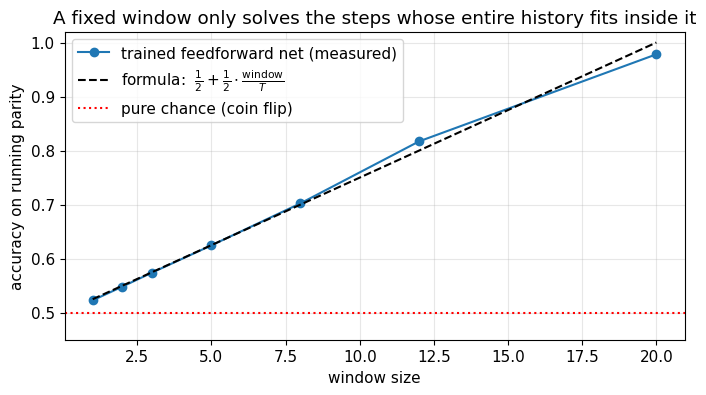

In [4]:
def make_sliding_windows(sequences, window):
    '''Turn each sequence into per-step windows of the last `window` bits.
    The start of each sequence is padded with zeros so every step has a full window.
    Output shape: (num_sequences, sequence_length, window).'''
    num_sequences, seq_len = sequences.shape
    zero_padding = np.zeros((num_sequences, window - 1))
    padded = np.concatenate([zero_padding, sequences], axis=1)
    windows = np.stack([padded[:, start:start + window] for start in range(seq_len)], axis=1)
    return windows

def train_feedforward_on_window(window, num_epochs=400):
    '''Train a small feedforward (MLP) network to predict running parity
    from a fixed window of recent bits. Returns its training accuracy.'''
    torch.manual_seed(0)
    window_features = make_sliding_windows(all_inputs, window).reshape(-1, window)
    inputs_tensor  = torch.tensor(window_features, dtype=torch.float32)
    targets_tensor = torch.tensor(all_parity.reshape(-1, 1), dtype=torch.float32)

    feedforward_net = nn.Sequential(
        nn.Linear(window, 64), nn.ReLU(),
        nn.Linear(64, 64),     nn.ReLU(),
        nn.Linear(64, 1),
    )
    optimizer = torch.optim.Adam(feedforward_net.parameters(), lr=1e-2)
    loss_function = nn.BCEWithLogitsLoss()
    for _ in range(num_epochs):
        optimizer.zero_grad()
        loss = loss_function(feedforward_net(inputs_tensor), targets_tensor)
        loss.backward()
        optimizer.step()

    predictions = (torch.sigmoid(feedforward_net(inputs_tensor)) > 0.5).float()
    accuracy = (predictions == targets_tensor).float().mean().item()
    return accuracy

sequence_length = all_inputs.shape[1]
window_sizes        = [1, 2, 3, 5, 8, 12, 20]
measured_accuracies = [train_feedforward_on_window(w) for w in window_sizes]
predicted_accuracies = [0.5 + 0.5 * w / sequence_length for w in window_sizes]

for w, measured, predicted in zip(window_sizes, measured_accuracies, predicted_accuracies):
    print(f"  window = {w:2d}:  measured accuracy = {measured:.3f}   (formula predicts {predicted:.3f})")

plt.figure()
plt.plot(window_sizes, measured_accuracies, "o-", label="trained feedforward net (measured)")
plt.plot(window_sizes, predicted_accuracies, "k--", label=r"formula:  $\frac{1}{2} + \frac{1}{2}\cdot\frac{\mathrm{window}}{T}$")
plt.axhline(0.5, color="red", ls=":", label="pure chance (coin flip)")
plt.xlabel("window size"); plt.ylabel("accuracy on running parity")
plt.title("A fixed window only solves the steps whose entire history fits inside it")
plt.legend(); plt.ylim(0.45, 1.02); plt.show()

The trained network follows the formula almost exactly. The conclusion is unavoidable: **to get every step right, the window would have to be as large as the whole sequence.** For sequences that can be arbitrarily long, that means an arbitrarily large input — which a fixed feedforward network simply does not have.

What we want instead is a model of **fixed size** that can nevertheless summarize a history of **unbounded length**. That running summary is called a **hidden state**, and the network that maintains it is the recurrent neural network.

## Part 2 — The fix: add a memory that feeds back into itself

Elman's idea (1990) is the smallest possible change. Keep a normal one-layer network, but give it a **hidden state** — a vector of numbers — that it passes to *itself* at the next time step. At each step the network reads two things: the current input, **and** its own hidden state from the previous step.

$$ \boxed{\; h_t \;=\; \tanh\!\big(W_{xh}\,x_t \;+\; W_{hh}\,h_{t-1} \;+\; b_h\big) \;} \qquad \hat{y}_t \;=\; \sigma\!\big(W_{hy}\,h_t + b_y\big), \qquad h_0 = \mathbf{0}. $$

Reading the boxed equation in words: *the new hidden state is a squashed (via $\tanh$) mix of the current input and the previous hidden state.* The three pieces are:

- $W_{xh}\,x_t$ — how the current input affects the new state ("input-to-hidden").
- $W_{hh}\,h_{t-1}$ — how the previous state affects the new state ("hidden-to-hidden"); **this is the memory channel.**
- $b_h$ — a bias.

And then a readout $W_{hy}\,h_t + b_y$ turns the state into a prediction ("hidden-to-output").

Notice how directly this answers Part 1's three failures:

| Feedforward failure | What recurrence does about it |
|---|---|
| can only see a fixed window of the past | $h_t$ is a learned, fixed-size summary of the **entire** history $x_1\ldots x_t$ |
| a separate weight per input position | the **same** weights $W_{xh}, W_{hh}, b_h$ are reused at **every** step |
| nowhere to store information across steps | the connection $h_{t-1} \to h_t$ **is** the memory |

Elman called $h_t$ the **context layer**. (Jordan's earlier network fed back the previous *output* $\hat y_{t-1}$ instead; feeding back the *hidden state* is what lets $h_t$ become a free, learnable memory that isn't forced to equal the prediction.)

### Unrolling: how we will train it
To train an RNN we **unroll** it in time: we lay out the same network once per time step and connect each step's hidden state to the next. The result is one big (very deep) network in which the weights are *shared* across all the steps. Once it's drawn out this way, it's just an ordinary feedforward network — and we can apply ordinary backpropagation. The only twist is that, because the weights are shared, a single weight collects gradient signal from **every** time step. That bookkeeping is what "Backpropagation Through Time" handles (Part 4).

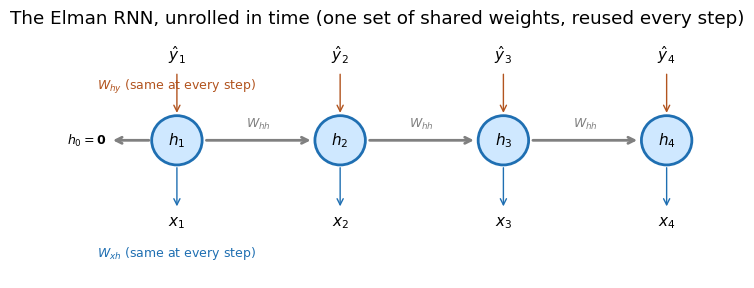

In [5]:
# A picture of the unrolled Elman network: one set of weights, reused at every step.
figure, axis = plt.subplots(figsize=(9, 3.2)); axis.axis("off")
step_x_positions = [0, 2.2, 4.4, 6.6]
for step_index, x in enumerate(step_x_positions):
    # the hidden-state "memory cell" at this step
    axis.add_patch(plt.Circle((x, 1.0), 0.34, fc="#cfe8ff", ec="#1f6fb2", lw=2, zorder=3))
    axis.text(x, 1.0, r"$h_{%d}$" % (step_index + 1), ha="center", va="center", zorder=4)
    # input arrow coming up from below
    axis.annotate("", (x, 0.66), (x, 0.05), arrowprops=dict(arrowstyle="<-", color="#1f6fb2"))
    axis.text(x, -0.18, r"$x_{%d}$" % (step_index + 1), ha="center")
    # output arrow going up
    axis.annotate("", (x, 1.95), (x, 1.34), arrowprops=dict(arrowstyle="<-", color="#b2541f"))
    axis.text(x, 2.1, r"$\hat y_{%d}$" % (step_index + 1), ha="center")
    # the memory connection to the next step
    if step_index < len(step_x_positions) - 1:
        next_x = step_x_positions[step_index + 1]
        axis.annotate("", (next_x - 0.36, 1.0), (x + 0.36, 1.0),
                      arrowprops=dict(arrowstyle="->", color="gray", lw=2))
        axis.text((x + next_x) / 2, 1.18, r"$W_{hh}$", ha="center", color="gray", fontsize=9)
axis.annotate("", (-0.9, 1.0), (-0.34, 1.0), arrowprops=dict(arrowstyle="->", color="gray", lw=2))
axis.text(-0.95, 1.0, r"$h_0=\mathbf{0}$", ha="right", va="center", fontsize=9)
axis.text(0, -0.6, r"$W_{xh}$ (same at every step)", ha="center", color="#1f6fb2", fontsize=9)
axis.text(0, 1.7, r"$W_{hy}$ (same at every step)", ha="center", color="#b2541f", fontsize=9)
axis.set_xlim(-2, 7.4); axis.set_ylim(-0.9, 2.5)
axis.set_title("The Elman RNN, unrolled in time (one set of shared weights, reused every step)")
plt.show()

## Part 3 — Writing the forward pass by hand

Let's pin down dimensions before writing code, because keeping shapes straight is most of the battle.

- We process a **batch** of `batch_size` sequences at once (for efficiency).
- Each input is a single bit, so the **input dimension** is `1`.
- The hidden state is a vector of length `hidden_size` (we'll use 16).
- The output is a single probability per step.

| quantity | symbol | array shape | meaning |
|---|---|---|---|
| input at step $t$ | $x_t$ | (batch_size, 1) | the current bit for each sequence |
| hidden state at step $t$ | $h_t$ | (batch_size, hidden_size) | the running memory |
| input-to-hidden weights | $W_{xh}$ | (hidden_size, 1) | how input drives the state |
| hidden-to-hidden weights | $W_{hh}$ | (hidden_size, hidden_size) | how the past drives the state |
| hidden bias | $b_h$ | (hidden_size,) | |
| hidden-to-output weights | $W_{hy}$ | (1, hidden_size) | readout |
| output bias | $b_y$ | (1,) | |

The forward pass, written with batches as rows (so we right-multiply by transposed weight matrices), is:

$$ \text{pre-activation}_t = x_t\,W_{xh}^\top + h_{t-1}\,W_{hh}^\top + b_h, \qquad h_t = \tanh(\text{pre-activation}_t), \qquad \text{logit}_t = h_t\,W_{hy}^\top + b_y. $$

We save **every** hidden state as we go, because the backward pass in Part 4 needs all of them.

In [6]:
def initialize_parameters(input_dim=1, hidden_size=16, seed=0):
    '''Create the five weight/bias arrays, with small random initial values.'''
    rng = np.random.default_rng(seed)
    scale = 1.0 / np.sqrt(hidden_size)     # a standard, gentle initialization scale
    return {
        "W_input_to_hidden":  rng.uniform(-scale, scale, (hidden_size, input_dim)),
        "W_hidden_to_hidden": rng.uniform(-scale, scale, (hidden_size, hidden_size)),
        "bias_hidden":        np.zeros(hidden_size),
        "W_hidden_to_output": rng.uniform(-scale, scale, (1, hidden_size)),
        "bias_output":        np.zeros(1),
    }

def rnn_forward(parameters, inputs):
    '''Run the RNN forward over a batch of sequences.

    Args:
      parameters: the dict from initialize_parameters
      inputs:     array of shape (batch_size, sequence_length, input_dim)

    Returns:
      output_logits:           (batch_size, sequence_length) raw scores (before sigmoid)
      hidden_states_over_time: list of length sequence_length+1; element t is h_t,
                               so element 0 is h_0 (all zeros) and element T is h_T.
    '''
    batch_size, sequence_length, _ = inputs.shape
    hidden_size = parameters["bias_hidden"].shape[0]

    hidden_state = np.zeros((batch_size, hidden_size))   # h_0 = 0
    hidden_states_over_time = [hidden_state.copy()]      # we will append h_1, h_2, ...
    output_logits = np.zeros((batch_size, sequence_length))

    for t in range(sequence_length):
        input_at_t = inputs[:, t, :]                     # shape (batch_size, input_dim)

        # the boxed recurrence from Part 2, written for a batch of rows:
        pre_activation = (
            input_at_t   @ parameters["W_input_to_hidden"].T   # current input's contribution
            + hidden_state @ parameters["W_hidden_to_hidden"].T  # the memory's contribution
            + parameters["bias_hidden"]
        )
        hidden_state = np.tanh(pre_activation)           # squash into (-1, 1); this is h_t
        hidden_states_over_time.append(hidden_state.copy())

        # read the state out into a single score for this step
        output_logits[:, t] = (
            hidden_state @ parameters["W_hidden_to_output"].T + parameters["bias_output"]
        )[:, 0]

    return output_logits, hidden_states_over_time

# Quick smoke test on 4 short sequences, with the network still untrained.
parameters = initialize_parameters(input_dim=1, hidden_size=16, seed=0)
demo_inputs, demo_targets = make_parity_dataset(num_sequences=4, sequence_length=8, seed=7)
demo_logits, demo_hidden_states = rnn_forward(parameters, demo_inputs[:, :, None])

print("input bits (4 sequences of length 8):")
print(demo_inputs.astype(int))
print("\nlogits shape:", demo_logits.shape)
print("number of saved hidden states:", len(demo_hidden_states), "(this is h_0 through h_8)")
print("untrained predicted P(parity=1) for sequence 0:", np.round(sigmoid(demo_logits[0]), 2))

input bits (4 sequences of length 8):
[[1 1 1 1 1 1 1 0]
 [0 0 0 1 1 0 0 1]
 [0 1 0 0 1 0 0 0]
 [1 0 1 0 0 1 1 1]]

logits shape: (4, 8)
number of saved hidden states: 9 (this is h_0 through h_8)
untrained predicted P(parity=1) for sequence 0: [0.49 0.49 0.49 0.49 0.49 0.49 0.49 0.49]


## Part 4 — Learning: deriving Backpropagation Through Time, step by step

This is the heart of the notebook. We will derive every gradient by hand. Take it slowly; each step is small.

### Step 0 — the loss
At each step the network outputs a probability $\hat p_t = \sigma(\text{logit}_t)$ that the parity is 1. We score it with **binary cross-entropy**, averaged over the batch and over time (so $N$ = batch size, $T$ = sequence length):

$$ \mathcal{L} \;=\; \frac{1}{NT}\sum_{n=1}^{N}\sum_{t=1}^{T}\; \Big[\, -\,y_t\log \hat p_t \;-\;(1-y_t)\log(1-\hat p_t)\,\Big]. $$

Our goal: compute $\partial \mathcal{L}/\partial \theta$ for every parameter $\theta \in \{W_{xh}, W_{hh}, b_h, W_{hy}, b_y\}$.

### Step 1 — gradient at the output (sigmoid + cross-entropy)
Let $z = \text{logit}_t$ and $p = \sigma(z)$. Using $\dfrac{d\sigma}{dz} = \sigma(z)\,(1-\sigma(z)) = p(1-p)$ and the per-step loss $\ell = -y\log p - (1-y)\log(1-p)$:

$$ \frac{\partial \ell}{\partial p} = -\frac{y}{p} + \frac{1-y}{1-p}, \qquad \frac{\partial \ell}{\partial z} = \frac{\partial \ell}{\partial p}\cdot \frac{\partial p}{\partial z} = \Big(-\frac{y}{p} + \frac{1-y}{1-p}\Big)\,p(1-p). $$

Multiply out and watch the mess cancel:

$$ \frac{\partial \ell}{\partial z} = -y(1-p) + (1-y)p = -y + yp + p - yp = \;p - y. $$

So, including the $\tfrac{1}{NT}$ averaging factor, the gradient flowing out of step $t$ is simply the **prediction minus the truth**:

$$ \delta_{\text{logit},\,t} \;\equiv\; \frac{\partial \mathcal{L}}{\partial\,\text{logit}_t} \;=\; \frac{1}{NT}\,(\hat p_t - y_t). $$

### Step 2 — the readout weights $W_{hy}, b_y$
Since $\text{logit}_t = h_t W_{hy}^\top + b_y$, and these weights are shared across all steps, we **sum the contribution from every step**:

$$ \frac{\partial \mathcal{L}}{\partial W_{hy}} = \sum_{t} \delta_{\text{logit},\,t}^{\,\top}\, h_t, \qquad \frac{\partial \mathcal{L}}{\partial b_y} = \sum_{t} \delta_{\text{logit},\,t}. $$

### Step 3 — the gradient w.r.t. a hidden state (this is "through time")
Here is the one genuinely new idea. A hidden state $h_t$ influences the loss through **two routes**:

1. **directly**, through this step's output $\hat y_t$;
2. **indirectly**, because $h_t$ is fed into the next step to help compute $h_{t+1}$ (which feeds $h_{t+2}$, and so on into the future).

By the chain rule, the total gradient on $h_t$ is the **sum of both routes**:

$$ \underbrace{\delta_{h,\,t}}_{\partial \mathcal L/\partial h_t} \;=\; \underbrace{\delta_{\text{logit},\,t}\,W_{hy}}_{\text{route 1: this step's output}} \;+\; \underbrace{\delta_{\text{pre-act},\,t+1}\,W_{hh}}_{\text{route 2: the future, via }h_{t+1}}. $$

This is a **backward recursion**: to get $\delta_{h,t}$ you need the next step's gradient, so we sweep from the last step $t=T$ back to the first $t=1$.

### Step 4 — push back through the $\tanh$
$h_t = \tanh(\text{pre-activation}_t)$, and $\tanh'(u) = 1 - \tanh(u)^2$. Since $h_t = \tanh(\cdot)$, this derivative is conveniently $1 - h_t^2$:

$$ \delta_{\text{pre-act},\,t} \;=\; (1 - h_t^2)\,\odot\,\delta_{h,\,t}, $$

where $\odot$ is elementwise multiplication.

### Step 5 — the recurrent weights $W_{xh}, W_{hh}, b_h$
The pre-activation is $\text{pre-act}_t = x_t W_{xh}^\top + h_{t-1} W_{hh}^\top + b_h$. Again the weights are shared, so we **sum over all steps**:

$$ \frac{\partial \mathcal{L}}{\partial W_{xh}} = \sum_t \delta_{\text{pre-act},\,t}^{\,\top}\, x_t, \qquad \frac{\partial \mathcal{L}}{\partial W_{hh}} = \sum_t \delta_{\text{pre-act},\,t}^{\,\top}\, h_{t-1}, \qquad \frac{\partial \mathcal{L}}{\partial b_h} = \sum_t \delta_{\text{pre-act},\,t}. $$

That's the entire algorithm. The code below is a direct transcription of Steps 1–5.

### A fully worked example: unrolling a 3-step sequence
To see *why* the gradient on $h_t$ has two routes, let's expand a short sequence completely. Take $T=3$. The forward pass is a chain:

$$ h_1 = \tanh(a_1),\quad h_2 = \tanh(a_2),\quad h_3 = \tanh(a_3), \qquad a_t = W_{xh}x_t + W_{hh}h_{t-1} + b_h, $$

and the loss is $\mathcal L = \ell_1 + \ell_2 + \ell_3$ (dropping the averaging constant for clarity), where each $\ell_t$ depends on $h_t$ through the output.

Now apply the chain rule to each hidden state, **starting from the last**:

- **Last step.** $h_3$ only affects $\ell_3$ (there is no step 4). So
$$ \delta_{h,3} = \frac{\partial \ell_3}{\partial h_3}. $$
- **Middle step.** $h_2$ affects $\ell_2$ directly, *and* affects everything downstream through $h_3$. So it gets two terms:
$$ \delta_{h,2} = \underbrace{\frac{\partial \ell_2}{\partial h_2}}_{\text{direct}} + \underbrace{\delta_{h,3}\,\frac{\partial h_3}{\partial h_2}}_{\text{through the future}}. $$
- **First step.** Likewise,
$$ \delta_{h,1} = \frac{\partial \ell_1}{\partial h_1} + \delta_{h,2}\,\frac{\partial h_2}{\partial h_1}. $$

That recursion — *direct term plus future term* — is exactly Step 3 above. And the step-to-step factor is the **Jacobian**

$$ \frac{\partial h_t}{\partial h_{t-1}} = \operatorname{diag}(1 - h_t^2)\,W_{hh}. $$

Finally, because $W_{hh}$ is reused in $a_1, a_2, a_3$, its total gradient is the **sum of three contributions**, one per step — which is the $\sum_t$ in Step 5. Unrolling further (to $T$ steps) shows that the gradient reaching back $k$ steps carries a **product of $k$ such Jacobians**:

$$ \prod_{j} \operatorname{diag}(1 - h_j^2)\,W_{hh}. $$

Keep this product in mind: a product of many matrices tends to shrink toward zero or blow up. That single fact is the whole story of Part 7.

In [7]:
def rnn_loss_and_gradients(parameters, inputs, targets):
    '''Forward pass + Backpropagation Through Time.

    Returns (loss, gradients_dict, predicted_probabilities).
    The gradients dict has the same keys as `parameters`.
    Each commented block below corresponds to a Step in the derivation above.
    '''
    batch_size, sequence_length, _ = inputs.shape
    hidden_size = parameters["bias_hidden"].shape[0]

    # ----- forward pass (Part 3) -----
    output_logits, hidden_states_over_time = rnn_forward(parameters, inputs)
    predicted_probs = sigmoid(output_logits)

    # ----- Step 0: the loss (binary cross-entropy, averaged) -----
    tiny = 1e-12   # guard against log(0)
    loss = -np.mean(
        targets * np.log(predicted_probs + tiny)
        + (1 - targets) * np.log(1 - predicted_probs + tiny)
    )

    # start every gradient at zero; we will ACCUMULATE into them across time steps
    gradients = {name: np.zeros_like(value) for name, value in parameters.items()}

    # this carries "route 2" — the gradient arriving from the future step h_{t+1}
    grad_hidden_from_future = np.zeros((batch_size, hidden_size))

    # sweep BACKWARD through time: from the last step to the first
    for t in reversed(range(sequence_length)):
        hidden_t        = hidden_states_over_time[t + 1]   # h_t  (index t+1 because index 0 is h_0)
        hidden_previous = hidden_states_over_time[t]        # h_{t-1}

        # ----- Step 1: gradient at the output = (prediction - truth), averaged -----
        grad_logit = (predicted_probs[:, t] - targets[:, t]) / (batch_size * sequence_length)
        grad_logit = grad_logit[:, None]                    # shape (batch_size, 1)

        # ----- Step 2: accumulate readout-weight gradients -----
        gradients["W_hidden_to_output"] += grad_logit.T @ hidden_t      # (1, hidden_size)
        gradients["bias_output"]        += grad_logit.sum(axis=0)       # (1,)

        # ----- Step 3: gradient on the hidden state = direct route + future route -----
        grad_hidden = grad_logit @ parameters["W_hidden_to_output"] + grad_hidden_from_future

        # ----- Step 4: push back through the tanh nonlinearity -----
        grad_pre_activation = (1.0 - hidden_t ** 2) * grad_hidden

        # ----- Step 5: accumulate recurrent-weight gradients -----
        gradients["W_input_to_hidden"]  += grad_pre_activation.T @ inputs[:, t, :]   # (hidden_size, input_dim)
        gradients["W_hidden_to_hidden"] += grad_pre_activation.T @ hidden_previous   # (hidden_size, hidden_size)
        gradients["bias_hidden"]        += grad_pre_activation.sum(axis=0)           # (hidden_size,)

        # prepare "route 2" for the PREVIOUS step (h_{t-1}): propagate through W_hh
        grad_hidden_from_future = grad_pre_activation @ parameters["W_hidden_to_hidden"]

    return loss, gradients, predicted_probs

### Trust, but verify: a numerical gradient check
A hand-derived gradient is only believable if we test it. We nudge each parameter by a tiny amount $\pm\epsilon$, measure how the loss actually changes (a finite-difference estimate of the slope), and compare to what our analytic gradient claims. If the two agree to about 9 decimal places, the derivation and the code are correct.

$$ \text{numerical gradient} \;\approx\; \frac{\mathcal{L}(\theta + \epsilon) - \mathcal{L}(\theta - \epsilon)}{2\epsilon}. $$

In [8]:
check_inputs, check_targets = make_parity_dataset(num_sequences=8, sequence_length=6, seed=1)
check_inputs = check_inputs[:, :, None]
check_parameters = initialize_parameters(input_dim=1, hidden_size=5, seed=2)

_, analytic_gradients, _ = rnn_loss_and_gradients(check_parameters, check_inputs, check_targets)
epsilon = 1e-5

print("Comparing our hand-derived gradients to numerical (finite-difference) gradients:\n")
print(f"{'parameter':22s}  max relative error")
for name in check_parameters:
    array = check_parameters[name]
    numerical_gradient = np.zeros_like(array)
    iterator = np.nditer(array, flags=["multi_index"])
    while not iterator.finished:
        index = iterator.multi_index
        original = array[index]
        array[index] = original + epsilon
        loss_plus, _, _ = rnn_loss_and_gradients(check_parameters, check_inputs, check_targets)
        array[index] = original - epsilon
        loss_minus, _, _ = rnn_loss_and_gradients(check_parameters, check_inputs, check_targets)
        array[index] = original
        numerical_gradient[index] = (loss_plus - loss_minus) / (2 * epsilon)
        iterator.iternext()
    relative_error = (np.abs(numerical_gradient - analytic_gradients[name]).max()
                      / (np.abs(numerical_gradient).max() + 1e-12))
    print(f"{name:22s}  {relative_error:.2e}")
print("\nErrors near 1e-9 mean the analytic Backpropagation Through Time is correct.")

Comparing our hand-derived gradients to numerical (finite-difference) gradients:

parameter               max relative error
W_input_to_hidden       3.36e-10
W_hidden_to_hidden      4.25e-09
bias_hidden             4.52e-10
W_hidden_to_output      3.24e-10
bias_output             2.53e-10

Errors near 1e-9 mean the analytic Backpropagation Through Time is correct.


## Part 5 — Training the RNN, and beating the feedforward baseline

Now we optimize the parameters with **Adam**, a popular gradient-descent variant that adapts the step size per parameter using running averages of the gradient (first moment) and its square (second moment). The training data is length-20 sequences.

The real test of *memory* comes after training: we evaluate on sequences **far longer than any seen during training**. A windowed feedforward network is capped by its window size and must fail on the longer steps. A true RNN learned a *rule that operates on its state*, so it should keep working no matter how long the sequence runs.

Training the from-scratch RNN on running parity:


  step  200   loss 0.4687   train accuracy 0.696


  step  400   loss 0.5020   train accuracy 0.711


  step  600   loss 0.0049   train accuracy 1.000


  step  800   loss 0.0021   train accuracy 1.000


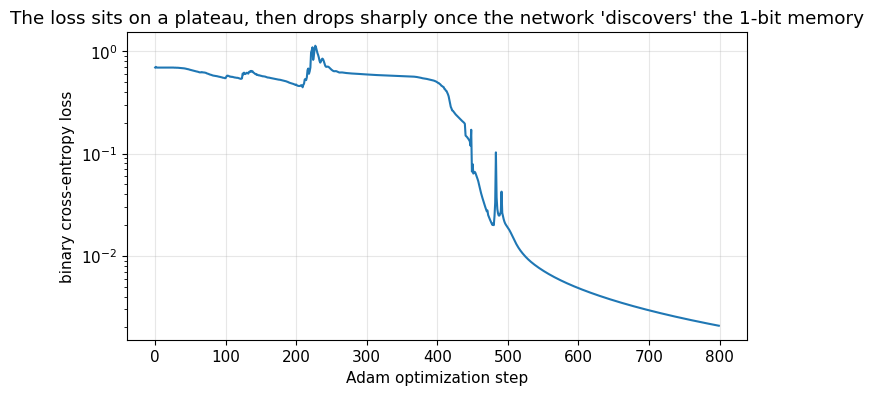

In [9]:
def train_rnn_on_parity(num_steps=800, learning_rate=5e-2, hidden_size=16,
                        train_length=20, num_train_sequences=1024, seed=3, log_every=200):
    '''Train the from-scratch RNN on running parity using the Adam optimizer.
    Returns the trained parameters and the list of loss values over training.'''
    train_inputs, train_targets = make_parity_dataset(num_train_sequences, train_length, seed=0)
    train_inputs = train_inputs[:, :, None]
    parameters = initialize_parameters(input_dim=1, hidden_size=hidden_size, seed=seed)

    # Adam keeps two running averages per parameter:
    first_moment  = {name: np.zeros_like(value) for name, value in parameters.items()}  # mean of gradient
    second_moment = {name: np.zeros_like(value) for name, value in parameters.items()}  # mean of gradient^2
    beta1, beta2, tiny = 0.9, 0.999, 1e-8

    loss_history = []
    for step in range(1, num_steps + 1):
        loss, gradients, _ = rnn_loss_and_gradients(parameters, train_inputs, train_targets)
        loss_history.append(loss)
        for name in parameters:
            g = gradients[name]
            first_moment[name]  = beta1 * first_moment[name]  + (1 - beta1) * g
            second_moment[name] = beta2 * second_moment[name] + (1 - beta2) * g ** 2
            # bias-correct the running averages (they start at zero)
            corrected_first  = first_moment[name]  / (1 - beta1 ** step)
            corrected_second = second_moment[name] / (1 - beta2 ** step)
            parameters[name] -= learning_rate * corrected_first / (np.sqrt(corrected_second) + tiny)

        if step % log_every == 0:
            logits, _ = rnn_forward(parameters, train_inputs)
            accuracy = ((sigmoid(logits) > 0.5) == train_targets).mean()
            print(f"  step {step:4d}   loss {loss:.4f}   train accuracy {accuracy:.3f}")
    return parameters, loss_history

print("Training the from-scratch RNN on running parity:")
trained_parameters, loss_history = train_rnn_on_parity()

plt.figure()
plt.plot(loss_history)
plt.xlabel("Adam optimization step"); plt.ylabel("binary cross-entropy loss")
plt.title("The loss sits on a plateau, then drops sharply once the network 'discovers' the 1-bit memory")
plt.yscale("log"); plt.show()

In [10]:
# The decisive comparison: test on sequences LONGER than anything seen in training.
print("Trained only on length-20 sequences. Now test on unseen lengths:\n")
print(f"{'sequence length':>16} | {'RNN accuracy':>13} | {'best window-20 feedforward':>27}")
print("-" * 62)
for test_length in [20, 30, 40, 60]:
    test_inputs, test_targets = make_parity_dataset(512, test_length, seed=100 + test_length)
    logits, _ = rnn_forward(trained_parameters, test_inputs[:, :, None])
    rnn_accuracy = ((sigmoid(logits) > 0.5) == test_targets).mean()
    # the theoretical ceiling of a window-20 feedforward net at this length:
    feedforward_ceiling = 0.5 + 0.5 * min(20, test_length) / test_length
    print(f"{test_length:>16} | {rnn_accuracy:>13.3f} | {feedforward_ceiling:>27.3f}")
print("\nThe RNN stays at ~100% as sequences get longer; the feedforward ceiling decays toward chance.")

Trained only on length-20 sequences. Now test on unseen lengths:

 sequence length |  RNN accuracy |  best window-20 feedforward
--------------------------------------------------------------
              20 |         1.000 |                       1.000
              30 |         1.000 |                       0.833
              40 |         1.000 |                       0.750


              60 |         1.000 |                       0.667

The RNN stays at ~100% as sequences get longer; the feedforward ceiling decays toward chance.


### Looking inside: what did the network actually learn?
Running parity needs exactly **one bit** of memory. If the RNN truly solved the task, some direction inside its hidden state should behave like a *parity register* — a value that flips every time a `1` arrives. Let's find the hidden unit whose activation most closely tracks the true running parity, and plot it.

Most parity-aligned hidden unit: #12  (|correlation| with true parity = 0.54)


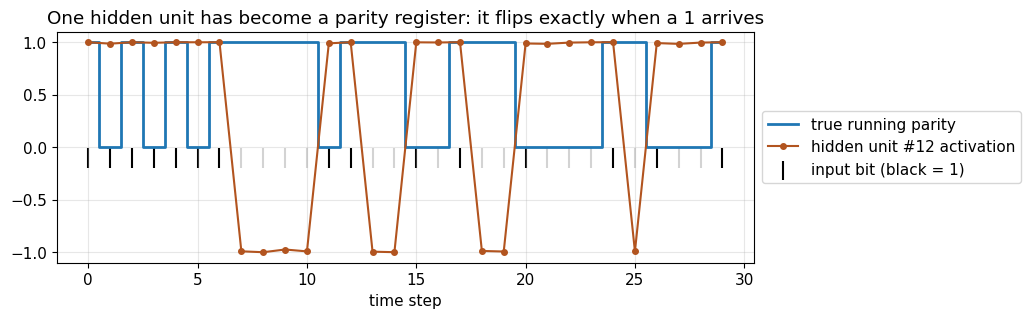

In [11]:
inspect_inputs, inspect_parity = make_parity_dataset(num_sequences=256, sequence_length=30, seed=7)
_, inspect_hidden_states = rnn_forward(trained_parameters, inspect_inputs[:, :, None])

# stack the saved states (skip h_0) into shape (batch, time, hidden_size)
hidden_matrix = np.stack(inspect_hidden_states[1:], axis=1)
parity_as_plus_minus_one = 2 * inspect_parity - 1     # map {0,1} -> {-1,+1}

# correlate each hidden unit's activation with the true parity, across all (sequence, time) points
correlations = np.array([
    np.corrcoef(hidden_matrix[:, :, unit].ravel(), parity_as_plus_minus_one.ravel())[0, 1]
    for unit in range(hidden_matrix.shape[2])
])
most_aligned_unit = int(np.nanargmax(np.abs(correlations)))
print(f"Most parity-aligned hidden unit: #{most_aligned_unit}  "
      f"(|correlation| with true parity = {abs(correlations[most_aligned_unit]):.2f})")

sequence_to_show = 0
figure, axis = plt.subplots(figsize=(9, 3))
axis.step(range(30), inspect_parity[sequence_to_show], where="mid",
          label="true running parity", lw=2)
axis.plot(range(30), hidden_matrix[sequence_to_show, :, most_aligned_unit], "o-", ms=4,
          color="#b2541f", label=f"hidden unit #{most_aligned_unit} activation")
axis.scatter(range(30), np.full(30, -0.1),
             c=["black" if bit else "lightgray" for bit in inspect_inputs[sequence_to_show]],
             marker="|", s=200, label="input bit (black = 1)")
axis.set_xlabel("time step")
axis.set_title("One hidden unit has become a parity register: it flips exactly when a 1 arrives")
axis.legend(loc="center left", bbox_to_anchor=(1, 0.5)); plt.show()

## Part 6 — The famous experiment: Elman's *"Finding Structure in Time"* (1990)

Parity proves an RNN can hold state. Elman's experiment shows why that matters for *language*: trained only to **predict the next item**, a recurrent network **discovers structure that nobody pointed out to it**.

### The setup (faithful to the paper)
Take a tiny vocabulary of made-up words, each a consonant followed by a fixed run of vowels:

> `ba`,   `dii`,   `guuu`

Now build a long stream by stringing together randomly chosen words **with no spaces, no markers, no word boundaries of any kind** — just an unbroken sequence of letters like `…guuudiibaba…`. Train an Elman RNN to predict the **next letter**, one character at a time.

### What we expect to see
*Within* a word, the next letter is completely determined once you've seen the first letter (`b`→`a`; `d`→`ii`; `g`→`uuu`). So a network with memory should predict those letters nearly perfectly. But the **first** letter of each word — i.e. *which word comes next* — is genuinely random. Therefore, if the network has learned the structure, its prediction error should:

- **spike** at the first letter of each word (unpredictable), and
- **fall to nearly zero** for the letters inside a word (predictable).

In other words, the error curve becomes a **word-boundary detector** — even though we never told the network what a word is.

In [12]:
vocabulary = ["ba", "dii", "guuu"]
alphabet = sorted(set("".join(vocabulary)))        # ['a', 'b', 'd', 'g', 'i', 'u']
letter_to_index = {letter: i for i, letter in enumerate(alphabet)}
vocabulary_size = len(alphabet)

def make_letter_stream(num_words, seed=0):
    '''Concatenate randomly chosen words into one long letter stream (no spaces).
    Also return, for each letter, its position within its word (0 = word-initial).'''
    rng = np.random.default_rng(seed)
    chosen_words = [vocabulary[i] for i in rng.integers(0, len(vocabulary), size=num_words)]
    stream = "".join(chosen_words)
    position_within_word = [pos for word in chosen_words for pos in range(len(word))]
    return stream, np.array(position_within_word)

training_stream, _ = make_letter_stream(num_words=2000, seed=0)
print("alphabet:", alphabet)
print("a slice of the unbroken training stream:")
print("  ", training_stream[:48], "...")
print(f"total length: {len(training_stream)} letters")

alphabet: ['a', 'b', 'd', 'g', 'i', 'u']
a slice of the unbroken training stream:
   guuudiidiibabababababaguuudiiguuudiidiiguuuguuud ...
total length: 6061 letters


In [13]:
# Encode the stream as one-hot vectors and set up next-letter prediction.
stream_indices = np.array([letter_to_index[letter] for letter in training_stream])
# inputs are letters 0..n-2, targets are letters 1..n-1 (predict the next letter)
inputs_one_hot = torch.nn.functional.one_hot(
    torch.tensor(stream_indices[:-1]), vocabulary_size).float().unsqueeze(0)  # (1, length, vocab)
next_letter_targets = torch.tensor(stream_indices[1:]).unsqueeze(0)           # (1, length)

class ElmanCharacterRNN(nn.Module):
    '''A compact Elman RNN: a recurrent layer followed by a linear readout to letter scores.'''
    def __init__(self, vocabulary_size, hidden_size=12):
        super().__init__()
        self.recurrent_layer = nn.RNN(vocabulary_size, hidden_size,
                                      batch_first=True, nonlinearity="tanh")
        self.readout = nn.Linear(hidden_size, vocabulary_size)
    def forward(self, sequence, hidden=None):
        recurrent_output, hidden = self.recurrent_layer(sequence, hidden)
        letter_scores = self.readout(recurrent_output)
        return letter_scores, hidden

torch.manual_seed(0)
character_rnn = ElmanCharacterRNN(vocabulary_size, hidden_size=12)
optimizer = torch.optim.Adam(character_rnn.parameters(), lr=5e-3)
cross_entropy = nn.CrossEntropyLoss()

print("Training the character-level Elman RNN to predict the next letter:")
for epoch in range(120):
    optimizer.zero_grad()
    letter_scores, _ = character_rnn(inputs_one_hot)
    loss = cross_entropy(letter_scores.reshape(-1, vocabulary_size),
                         next_letter_targets.reshape(-1))
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 40 == 0:
        print(f"  epoch {epoch + 1:3d}   cross-entropy {loss.item():.4f}")

Training the character-level Elman RNN to predict the next letter:


  epoch  40   cross-entropy 1.1794


  epoch  80   cross-entropy 0.4983


  epoch 120   cross-entropy 0.4010


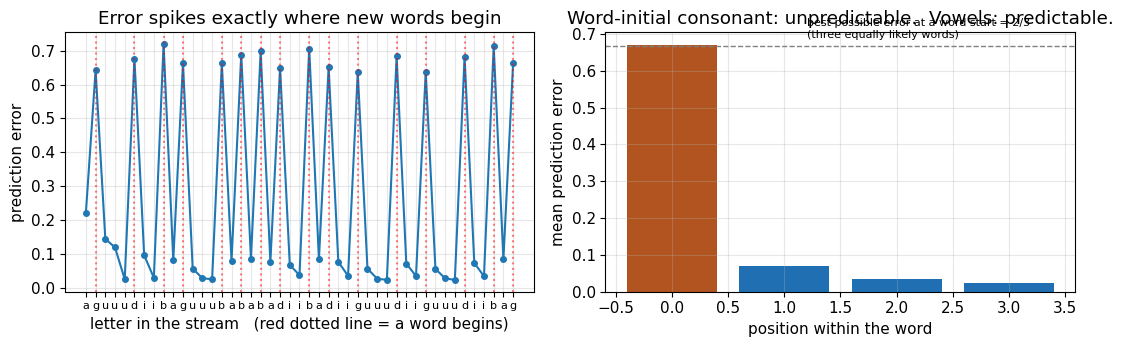

mean prediction error by within-word position: [np.float32(0.671), np.float32(0.069), np.float32(0.034), np.float32(0.025)]


In [14]:
# Evaluate on a FRESH stream the network never trained on.
# Prediction error = 1 - (probability the model assigned to the letter that actually came next).
test_stream, position_within_word = make_letter_stream(num_words=400, seed=123)
test_indices = np.array([letter_to_index[letter] for letter in test_stream])
test_inputs_one_hot = torch.nn.functional.one_hot(
    torch.tensor(test_indices[:-1]), vocabulary_size).float().unsqueeze(0)
test_next_letters = test_indices[1:]

with torch.no_grad():
    test_scores, _ = character_rnn(test_inputs_one_hot)
    predicted_probabilities = torch.softmax(test_scores[0], dim=-1).numpy()

probability_of_true_next_letter = predicted_probabilities[
    np.arange(len(test_next_letters)), test_next_letters]
prediction_error = 1 - probability_of_true_next_letter
position_of_predicted_letter = position_within_word[1:]   # within-word position of each target letter

figure, (left_axis, right_axis) = plt.subplots(1, 2, figsize=(11, 3.6))

# LEFT: Elman's iconic figure — error along the stream, with word starts marked.
window_slice = slice(0, 45)
left_axis.plot(range(45), prediction_error[window_slice], "o-", ms=4)
for i in range(45):
    if position_of_predicted_letter[window_slice][i] == 0:    # a word-initial letter
        left_axis.axvline(i, color="red", ls=":", alpha=0.5)
left_axis.set_xticks(range(45))
left_axis.set_xticklabels(list(test_stream[1:46]), fontsize=8)
left_axis.set_xlabel("letter in the stream   (red dotted line = a word begins)")
left_axis.set_ylabel("prediction error")
left_axis.set_title("Error spikes exactly where new words begin")

# RIGHT: average error grouped by position within the word.
max_position = position_of_predicted_letter.max()
mean_error_by_position = [prediction_error[position_of_predicted_letter == k].mean()
                          for k in range(max_position + 1)]
bar_colors = ["#b2541f"] + ["#1f6fb2"] * max_position
right_axis.bar(range(max_position + 1), mean_error_by_position, color=bar_colors)
right_axis.set_xlabel("position within the word"); right_axis.set_ylabel("mean prediction error")
right_axis.set_title("Word-initial consonant: unpredictable.  Vowels: predictable.")
right_axis.axhline(2/3, color="gray", ls="--", lw=1)
right_axis.text(max_position * 0.4, 0.69,
                "best possible error at a word start = 2/3\n(three equally likely words)", fontsize=8)
plt.tight_layout(); plt.show()

print("mean prediction error by within-word position:",
      [round(value, 3) for value in mean_error_by_position])

Read the right panel: the word-initial consonant sits at error $\approx 2/3$, which is the **best any model could possibly do** — there are three equally likely words, so the smartest guess still puts only $1/3$ of its probability on the correct first letter, leaving $2/3$ error. Every vowel position, by contrast, collapses to nearly zero error. The left panel is Elman's celebrated figure: feed the trained network an unbroken letter stream, and its prediction error climbs right where each new word starts and falls as the word plays out.

No one told the network where words begin. It inferred that structure purely from the statistics of next-letter prediction over time — **because it had a hidden state in which to accumulate that structure.** That is the central message of *"Finding Structure in Time,"* and the reason recurrence became the default approach to language for the next twenty-five years.

## Part 7 — The catch: simple RNNs forget, and that leads to LSTMs

Remember the gradient object from Part 4's worked example: a signal crossing $k$ time steps gets multiplied by a **product of $k$ Jacobians**, $\prod_j \operatorname{diag}(1 - h_j^2)\,W_{hh}$. Whether that product grows or shrinks is governed (roughly) by the **largest eigenvalue magnitude** of $W_{hh}$, called its *spectral radius* $\rho$. The $\tanh$ factor $1 - h^2 \le 1$ only ever shrinks things further. So:

- if $\rho < 1$, the product **shrinks geometrically** → gradients **vanish** → the network cannot learn dependencies more than a few steps back;
- if $\rho > 1$, the product can **grow geometrically** → gradients **explode**.

Let's watch it happen directly. We push a unit gradient backward through a random RNN and track its size as a function of how far back in time it has travelled.

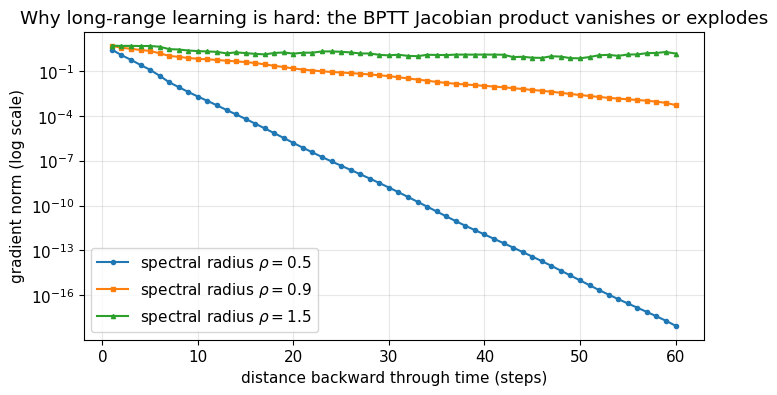

At spectral radius 0.5 the gradient loses ~18 orders of magnitude over 60 steps:
any learning signal from far in the past has effectively disappeared.


In [15]:
def gradient_norm_versus_distance(spectral_radius, num_steps=60, hidden_size=32, seed=0):
    '''Backpropagate a unit gradient through a random RNN whose recurrent matrix has a
    chosen spectral radius. Return the gradient's norm at each distance back in time.'''
    rng = np.random.default_rng(seed)
    recurrent_matrix = rng.standard_normal((hidden_size, hidden_size))
    # rescale so the largest eigenvalue magnitude equals the requested spectral radius
    largest_eigenvalue = np.max(np.abs(np.linalg.eigvals(recurrent_matrix)))
    recurrent_matrix = recurrent_matrix / largest_eigenvalue * spectral_radius

    # run a quick forward pass to get plausible hidden states
    hidden = np.tanh(rng.standard_normal(hidden_size))
    hidden_states = [hidden]
    for _ in range(num_steps):
        hidden = np.tanh(recurrent_matrix @ hidden + 0.1 * rng.standard_normal(hidden_size))
        hidden_states.append(hidden)

    # backpropagate a random unit signal and record its norm at each step
    gradient = rng.standard_normal(hidden_size)
    norms = []
    for t in reversed(range(num_steps)):
        gradient = recurrent_matrix.T @ ((1 - hidden_states[t + 1] ** 2) * gradient)
        norms.append(np.linalg.norm(gradient))
    return np.array(norms[::-1])

plt.figure()
for spectral_radius, marker in [(0.5, "o-"), (0.9, "s-"), (1.5, "^-")]:
    norms = gradient_norm_versus_distance(spectral_radius)
    plt.semilogy(range(1, len(norms) + 1), norms[::-1], marker, ms=3,
                 label=fr"spectral radius $\rho={spectral_radius}$")
plt.xlabel("distance backward through time (steps)")
plt.ylabel("gradient norm (log scale)")
plt.title("Why long-range learning is hard: the BPTT Jacobian product vanishes or explodes")
plt.legend(); plt.show()
print("At spectral radius 0.5 the gradient loses ~18 orders of magnitude over 60 steps:")
print("any learning signal from far in the past has effectively disappeared.")

This is exactly the obstacle **Bengio, Simard & Frasconi (1994)** analyzed, and it is what **Hochreiter & Schmidhuber's LSTM (1997)** was built to defeat. An LSTM adds a gated *memory cell* with an **additive** update path whose Jacobian stays close to 1, so gradients can flow across hundreds of steps without vanishing or exploding. **GRUs** (Cho et al., 2014) are a streamlined version of the same idea. Crucially, **everything you learned here carries over unchanged** — hidden state, weight sharing, unrolling, Backpropagation Through Time. LSTMs and GRUs only swap out the cell's internal update equation for one that protects the gradient.

### Recap of the whole story
1. **The problem.** When the answer depends on unbounded history, a fixed-window feedforward network is capped at accuracy $\tfrac12 + \tfrac12\cdot \tfrac{\text{window}}{T}$ — provably blind beyond its window.
2. **The fix.** Recurrence: a fixed-size hidden state $h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)$ that summarizes the entire past, using the *same* weights at every step.
3. **The learning rule.** Backpropagation Through Time — ordinary backprop on the unrolled network, with each shared weight's gradient summed over all steps. We derived it line by line and verified it numerically to about nine decimal places.
4. **Why it matters.** Trained only to predict the next letter, an Elman RNN recovered word boundaries from an unsegmented stream — Elman (1990).
5. **The limit.** The same Jacobian product that grants memory also makes long-range gradients vanish — which is precisely the door that LSTMs and GRUs walk through.

### References
- Elman, J. L. (1990). *Finding Structure in Time.* Cognitive Science, 14(2), 179–211.
- Jordan, M. I. (1986). *Serial Order: A Parallel Distributed Processing Approach.* UCSD ICS Report 8604.
- Rumelhart, Hinton & Williams (1986). *Learning representations by back-propagating errors.* Nature, 323, 533–536.
- Werbos, P. J. (1990). *Backpropagation Through Time.* Proceedings of the IEEE, 78(10), 1550–1560.
- Bengio, Simard & Frasconi (1994). *Learning long-term dependencies with gradient descent is difficult.* IEEE TNN, 5(2), 157–166.
- Hochreiter & Schmidhuber (1997). *Long Short-Term Memory.* Neural Computation, 9(8), 1735–1780.
- Cho et al. (2014). *Learning Phrase Representations using RNN Encoder–Decoder.* arXiv:1406.1078.